In [99]:
from datascience import * 
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plt 

In [ ]:
exoplanet_csv = "koi_dataset.csv"
exoplanets = Table().read_table(exoplanet_csv)
exoplanets

In [291]:
cleaned_exoplanets = exoplanets.where("koi_vet_stat", are.equal_to("Done")).where("koi_disposition", are.not_equal_to("CANDIDATE")).where("koi_model_snr", are.not_equal_to(np.nan))

ninety_percentile = np.nanpercentile(cleaned_exoplanets.column("koi_model_snr"), 90)
confirmed = cleaned_exoplanets.where("koi_model_snr", are.below_or_equal_to(ninety_percentile)).where("koi_disposition", are.equal_to("CONFIRMED"))
false_positives = cleaned_exoplanets.where("koi_model_snr", are.below_or_equal_to(ninety_percentile)).where("koi_disposition", are.equal_to("FALSE POSITIVE"))

## TRANSIT PROPERTIES

Disposition,Number,Average SNR,Median SNR,Max SNR,Min SNR,Std Dev,90th Percentile
Confirmed,2703,52.5542,28.25,871.4,5.9,83.7525,97.17
False Positive,3889,103.537,22.7,885.9,0,177.751,336.48


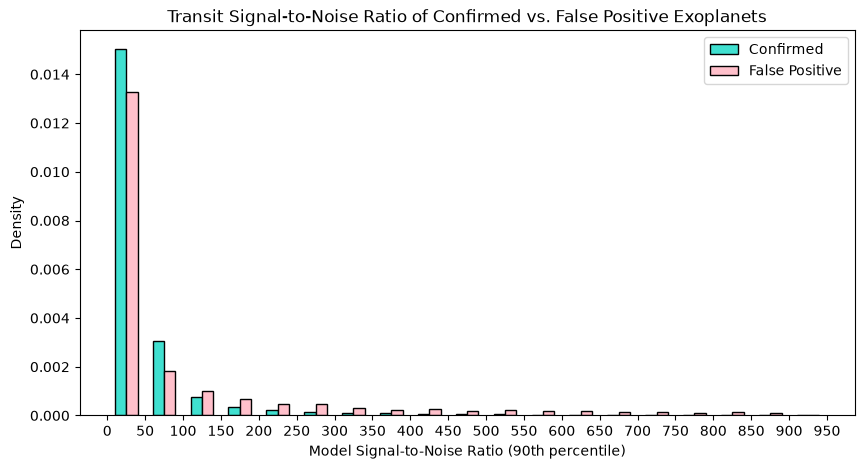

In [338]:
snr_confirmed = confirmed.column("koi_model_snr")
snr_fp = false_positives.column("koi_model_snr")

plt.figure(figsize=(10,5))

plt.hist(
    [snr_confirmed, snr_fp], 
    bins=np.arange(0, 1000, 50),
    histtype="bar",
    align="mid",
    density=True, 
    label=["Confirmed", "False Positive"], 
    color=["turquoise", "pink"],
    rwidth=0.6
)

plt.xticks(np.arange(0, 1000, 50))
plt.xlabel("Model Signal-to-Noise Ratio (90th percentile)")
plt.ylabel("Density")
plt.title("Transit Signal-to-Noise Ratio of Confirmed vs. False Positive Exoplanets")
plt.legend()

snr_stats = Table().with_columns(
    "Disposition", ["Confirmed", "False Positive"],
    "Number", [confirmed.num_rows-1, false_positives.num_rows-1],
    "Average SNR", [np.mean(snr_confirmed), np.mean(snr_fp)], 
    "Median SNR", [np.median(snr_confirmed), np.median(snr_fp)],
    "Max SNR", [np.max(snr_confirmed), np.max(snr_fp)],
    "Min SNR", [np.min(snr_confirmed), np.min(snr_fp)],
    "Std Dev", [np.std(snr_confirmed), np.std(snr_fp)],
    "90th Percentile", [np.percentile(snr_confirmed, 90), np.percentile(snr_fp, 90)]
)

snr_stats

In [ ]:
# add stats like mean, median, percentiles on graph


Text(0.5, 1.0, 'Probability of Confirmed Exoplanets by Signal-to-Noise Ratio')

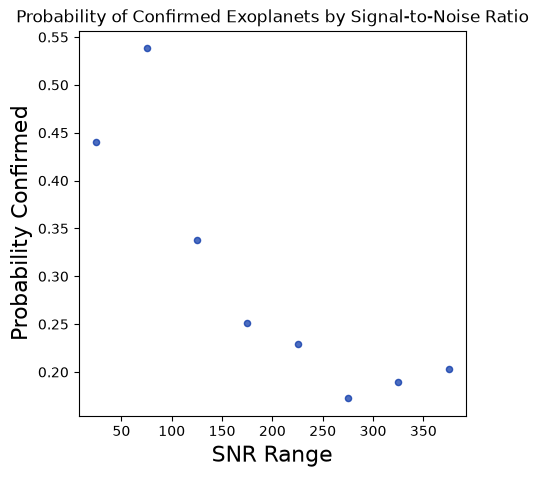

In [335]:
bins = np.arange(0, 450, 50)
confirmed_count, edges = np.histogram(snr_confirmed, bins=bins)
fp_count, _ = np.histogram(snr_fp, bins=bins)
probability_confirmed = confirmed_count / (confirmed_count+fp_count)

midpts = (edges[:-1] + edges[1:]) /2

results = Table().with_columns(
    "SNR Range", midpts,
    "Probability Confirmed", probability_confirmed
)

results.scatter("SNR Range")
plt.title("Probability of Confirmed Exoplanets by Signal-to-Noise Ratio")

In [ ]:
midpoints = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 6))

plt.plot(
    midpoints,
    probability_confirmed,
    marker="o",
    linewidth=2
)

plt.xlabel("Model Signal-to-Noise Ratio (SNR)")
plt.ylabel("Probability of Confirmation")
plt.title("Probability of Exoplanet Confirmation vs. Signal-to-Noise Ratio")

plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.show()

## PLANETARY PROPERTIES

## STELLAR PROPERTIES